In [149]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so
import math
mapping = {
    "faceBased": "Face-Based",
    "globalFaceBased": "Face-Based Global",
    "batchedFace": "Face-Based Batched",
    "cellBased": "Cell-Based",
    "optimal": "Ideal Speedup",
}

df = pd.read_csv("../results/icoFoam-mpi.csv", skip_blank_lines=True)


In [150]:
def setup_df(base_df: pd.DataFrame) -> pd.DataFrame:
    base_df["cells"] = [int(x.rsplit("/", 2)[1]) ** 3 for x in base_df["case_long"]]
    base_df["ms_normed"] = base_df["time_mean_ms"] / base_df["cells"]
    base_df = base_df[base_df["executor"] == "cpu"]
    base_df["Threads"] = [
        int(x.split("-")[1]) if x.split("-")[1] != "serial" else 1
        for x in base_df["variant"]
    ]
    base_df["cellsPerCpu"] = base_df["cells"] / base_df["Threads"]
    base_df["logth"] = [int(math.log2(x)) for x in base_df["Threads"]]
    group_cols = [
        "case_long",
        "strategy",
        "language",
        "precision",
        "executor",
        "use_kernelAbstractions",
        "use_fusing",
    ]

    baseline = (
        base_df[base_df["variant"].str.contains("serial")]
        .groupby(group_cols, as_index=False)["time_mean_ms"]
        .first()
        .rename(columns={"time_mean_ms": "serial_time"})
    )

    base_df = base_df.merge(baseline, on=group_cols, how="left")
    base_df["speedup"] = base_df["serial_time"] / base_df["time_mean_ms"]
    base_df["efficiency"] = base_df["speedup"] / base_df["Threads"]

    sb.set_theme()
    base_df["logthp1"] = base_df["logth"] + 1
    mapping = {
        "faceBased": "Face-Based",
        "globalFaceBased": "Face-Based Global",
        "batchedFace": "Face-Based Batched",
        "cellBased": "Cell-Based",
        "optimal": "Ideal Speedup",
    }
    bins = [0, 50000, 100000, 300000, 500000, max(base_df["cellsPerCpu"])]
    labels = ["0-50k", "50k-100k", "100k-300k", "300k-500k", "500k+"]

    base_df["CPTranges"] = pd.cut(base_df["cellsPerCpu"], bins=bins, labels=labels)
    base_df["case_num"] = base_df["case_long"].str.extract(r"(\d+)/?$").astype(int)

    # build sorted order
    order = (
        base_df[["case_long", "case_num"]]
        .drop_duplicates()
        .sort_values("case_num")["case_long"]
    )
    ncells = sorted((round(base_df["cells"] ** (1 / 3))).unique().astype(int))
    strats = ["faceBased", "globalFaceBased", "batchedFace", "cellBased"]
    base_df["avg_time"] = base_df.groupby(["Threads", "strategy"])[
         "time_mean_ms"
    ].transform("mean")
    base_df["avg_speedup"] = base_df.groupby(["Threads", "strategy"])[
        "speedup"
    ].transform("mean")
    base_df["avg_efficiency"] = base_df.groupby(["Threads", "strategy"])[
        "efficiency"
    ].transform("mean")
    base_df["avg_normed"] = base_df.groupby(["cells", "strategy"])[
        "ms_normed"
    ].transform("mean")
    base_df["sThreds"] = [f"{x}" for x in base_df["Threads"]]
    base_df["strategy_display"] = [mapping[s] for s in base_df["strategy"]]
    tmap = {np.int64(1): 0,
        np.int64(2): 1,
        np.int64(4): 2,
        np.int64(8): 3,
        np.int64(16): 4,
        np.int64(24): 5,
        np.int64(32): 6,
        np.int64(64): 7,
        np.int64(128): 8,
        np.int64(256): 9}
    base_df["threadindex"] = base_df["Threads"].apply(lambda x: tmap[x]+1)

    return base_df

In [151]:
julia = pd.read_csv("../results/cpuScaling.csv", skip_blank_lines=True)
julia["Threads"] = [
    int(x.split("-")[1]) if x.split("-")[1] != "serial" else 1
    for x in julia["variant"]
]
julia_serial = julia[julia["Threads"] == 1]
julia_serial["cells"] = [int(x.rsplit("/", 2)[1]) ** 3 for x in julia_serial["case_long"]]
julia_serial["ms_normed"] = julia_serial["time_mean_ms"] / julia_serial["cells"]
julia_serial["time_ms"] = julia_serial["time_mean_ms"]

julia_serial["strategy_display"] = [mapping[s] for s in julia_serial["strategy"]]


In [153]:
julia

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,precision,...,logthp1,CPTranges,case_num,avg_time,avg_speedup,avg_efficiency,avg_normed,sThreds,strategy_display,threadindex
0,0.037793,0.037385,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,faceBased,SOAFusedFaceBasedAssembly-serial,julia,float64,...,1,0-50k,10,68.258603,1.000000,1.000000,0.000308,1,Face-Based,1
1,0.042688,0.042405,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,globalFaceBased,FusedGlobalFaceBased-serial,julia,float64,...,1,0-50k,10,70.452340,1.000000,1.000000,0.000297,1,Face-Based Global,1
2,0.040381,0.040413,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,batchedFace,FusedBatchedFaceBased-serial,julia,float64,...,1,0-50k,10,78.984554,1.000000,1.000000,0.001938,1,Face-Based Batched,1
3,0.045167,0.044763,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,faceBased,SOAFusedFaceBasedAssemblyThreaded-2,julia,float64,...,2,0-50k,10,58.009064,1.124642,0.562321,0.000308,2,Face-Based,2
4,0.040647,0.040289,0.0,0.0,cases/Lid-Driven-Cavities/10/,cases/Lid-Driven-Cavities/10/,globalFaceBased,FusedGlobalFaceBased-2,julia,float64,...,2,0-50k,10,58.694350,1.182329,0.591164,0.000297,2,Face-Based Global,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,65.491149,65.209862,0.0,0.0,cases/Lid-Driven-Cavities/180/,cases/Lid-Driven-Cavities/180/,cellBased,FusedCellBased-24,julia,float64,...,5,100k-300k,180,19.766448,7.248666,0.302028,0.000024,24,Cell-Based,6
596,58.843583,58.349695,0.0,0.0,cases/Lid-Driven-Cavities/200/,cases/Lid-Driven-Cavities/200/,faceBased,SOAFusedFaceBasedAssemblyThreaded-24,julia,float64,...,5,300k-500k,200,12.816861,4.646172,0.193590,0.000015,24,Face-Based,6
597,55.790764,56.342130,0.0,0.0,cases/Lid-Driven-Cavities/200/,cases/Lid-Driven-Cavities/200/,globalFaceBased,FusedGlobalFaceBased-24,julia,float64,...,5,300k-500k,200,12.035274,5.486458,0.228602,0.000015,24,Face-Based Global,6
598,183.696063,183.553949,0.0,0.0,cases/Lid-Driven-Cavities/200/,cases/Lid-Driven-Cavities/200/,batchedFace,FusedBatchedFaceBased-24,julia,float64,...,5,300k-500k,200,38.202888,2.360488,0.098354,0.000026,24,Face-Based Batched,6


In [152]:
julia = setup_df(julia)

In [ ]:

p = sb.relplot(data=df, x="cells", y="ms_normed", height=10, hue="np_string", kind="line")
axes = p.axes.flat
# for ax in axes:
#     sb.scatterplot(ax=ax, data=julia_serial, x="cells", y="ms_normed")
#     ax.set_xscale("log")
p.set(
    yscale="log",
)

In [209]:
all = pd.concat([julia, df])

In [ ]:
sb.set_style("whitegrid")
sb.color_palette("deep", 8)
plot =sb.relplot(data=all[all["Threads"] == 1], x="cells", y="ms_normed", hue="strategy_display", height=10, s=80, style="strategy_display")
plot.set(
    yscale="log",
    xscale="log"
)
plot.legend.set_title("Strategy")

In [ ]:
sb.set_style("whitegrid")
sb.color_palette("deep", 8)
plot =sb.relplot(data=all, x="cells", y="time_ms", hue="strategy", height=10, s=80, style="strategy")
plot.set(
    yscale="log",
    xscale="log"
)

In [ ]:
def setup_icofoam(base_df: pd.DataFrame) -> pd.DataFrame:
    base_df["time_ms"] = base_df["time_s"] * 1000
    base_df["cells"] = base_df["cell_dim"].apply(lambda x: x**3)
    base_df["ms_normed"] = base_df["time_ms"] / base_df["cells"]
    base_df["time_mean_ms"] = base_df["time_ms"]
    base_df["strategy"] = "IcoFoam"
    base_df["strategy_display"] = "IcoFoam"
    base_df["np_string"] = base_df["nprocs"].apply(lambda x: str(x))
    base_df["Threads"] = base_df["nprocs"]
    base_df["ms_normed"] = base_df["time_mean_ms"] / base_df["cells"]
    base_df["cellsPerCpu"] = base_df["cells"] / base_df["Threads"]
    base_df["logth"] = [int(math.log2(x)) for x in base_df["Threads"]]

    baseline = (
        base_df[base_df["nprocs"] == 1]
        .groupby(["cells"], as_index=False)["time_ms"]
        .first()
        .rename(columns={"time_ms": "serial_time"})
    )

    base_df = base_df.merge(baseline, on=["cells"], how="left")
    base_df["speedup"] = base_df["serial_time"] / base_df["time_mean_ms"]
    base_df["efficiency"] = base_df["speedup"] / base_df["Threads"]

    sb.set_theme()
    base_df["logthp1"] = base_df["logth"] + 1
    mapping = {
        "faceBased": "Face-Based",
        "globalFaceBased": "Face-Based Global",
        "batchedFace": "Face-Based Batched",
        "cellBased": "Cell-Based",
        "optimal": "Ideal Speedup",
    }
    bins = [0, 50000, 100000, 300000, 500000, max(base_df["cellsPerCpu"])]
    labels = ["0-50k", "50k-100k", "100k-300k", "300k-500k", "500k+"]

    base_df["CPTranges"] = pd.cut(base_df["cellsPerCpu"], bins=bins, labels=labels)
    base_df["avg_time"] = base_df.groupby(["Threads"])[
         "time_mean_ms"
    ].transform("mean")
    base_df["avg_speedup"] = base_df.groupby(["Threads"])[
        "speedup"
    ].transform("mean")
    base_df["avg_efficiency"] = base_df.groupby(["Threads"])[
        "efficiency"
    ].transform("mean")
    base_df["avg_normed"] = base_df.groupby(["cells", "strategy"])[
        "ms_normed"
    ].transform("mean")
    base_df["sThreds"] = [f"{x}" for x in base_df["Threads"]]
    tmap = {np.int64(1): 0,
        np.int64(2): 1,
        np.int64(4): 2,
        np.int64(8): 3,
        np.int64(16): 4,
        np.int64(24): 5,
        np.int64(32): 6,
        np.int64(64): 7,
        np.int64(128): 8,
        np.int64(256): 9}
    base_df["threadindex"] = base_df["Threads"].apply(lambda x: tmap[x]+1)

    return base_df

In [154]:
df =setup_icofoam(df)

In [ ]:
def scaling_ms(data):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)

    with sb.plotting_context("paper", font_scale=1.5):
        plot = sb.relplot(data=data, x="logthp1", y="time_mean_ms", kind="scatter", hue="np_string",s=60)
        axes = plot.axes.flat

        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data,
                x="logthp1",
                y="time_mean_ms",
                hue="strategy",
                legend=False,   # avoid duplicate legends
                ax=ax
            )
            ax.tick_params(labelbottom=True)
            ax.set_xticks(list(range(1,1+len(data["Threads"].unique()))))
            ax.set_xticklabels(labels=data["Threads"].unique())
            ax.set_xlabel("Threads")
            ax.plot([1,9], [1,9], color='k',linestyle="dashed", label="Ideal Speedup")
            ax.set_yticks(list(range(1,10)))

            # plot.legend(False)
        # sb.move_legend(plot, "upper left", bbox_to_anchor=(0.1 ,0.9))
        handles, labels = axes[0].get_legend_handles_labels()
        plot.legend.remove()
        # plot.set(
        #     ylabel="Speedup"
        # )
        plt.ylabel("Speedup", fontsize=30)
        axes[0].legend(handles, labels, loc="upper left",
                        title="Strategy")

        plt.tight_layout()
scaling_ms(df)


In [ ]:
scaling_ms(df)

[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(24), np.int64(32), np.int64(64), np.int64(128)]


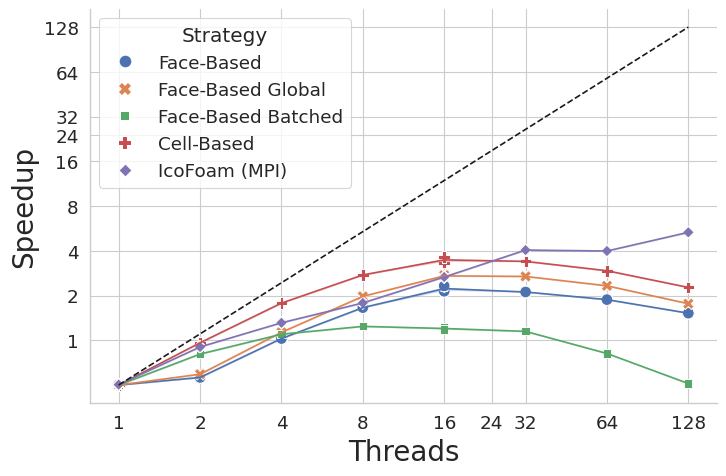

In [221]:
import numpy as np

def scaling_speedup(data):
    sb.set_style("whitegrid")

    # transform once
    data = data.copy()
    data["log_speedup"] = np.log2(data["avg_speedup"])

    with sb.plotting_context("paper", font_scale=1.5):
        plot = sb.relplot(
            data=data,
            x="logthp1",
            y="log_speedup",  
            kind="scatter",
            style="strategy_display",
            hue="strategy_display",
            s=70
        )

        axes = plot.axes.flat

        for ax in axes:
            sb.lineplot(
                data=data,
                x="logthp1",
                y="log_speedup",
                hue="strategy_display",
                legend=False,
                ax=ax,
            )

            # Ideal scaling: speedup = threads → log2(s) = log2(t)
            # x_vals = sorted(data["logthp1"].unique())
            x_vals = sorted(np.log2(data["Threads"].unique()) +1)
            ax.plot([1,8], [0,8], color='k',linestyle="dashed", label="Ideal Speedup")

            threads = sorted(data["Threads"].unique())
            print(threads)
            
            ax.set_xticks(x_vals)
            ax.set_xticklabels(threads)

            ax.set_yticks(x_vals)
            ax.set_yticklabels(threads)

        handles, _ = axes[0].get_legend_handles_labels()
        plot.legend.remove()

        axes[0].legend(
            handles,
            data["strategy_display"].unique(),
            loc="upper left",
            title="Strategy"
        )

        plt.ylabel("Speedup", fontsize=20)
        plt.xlabel("Threads", fontsize=20)
        plt.tight_layout()
        plt.savefig("../figures/icoFoam-julia-speedup.svg")
df["strategy_display"] = "IcoFoam (MPI)"
scaling_speedup(all[all["Threads"] < 256])

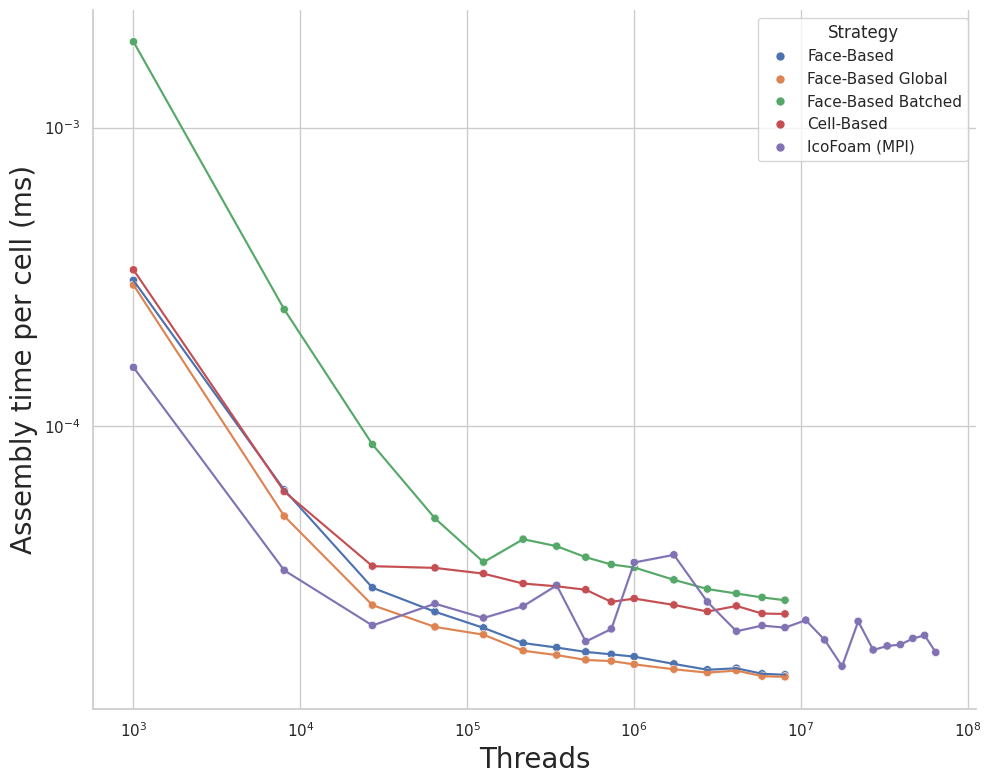

In [255]:
df["st"] = df["Threads"].apply(lambda x: str(x))
plot = sb.relplot(data=all[all["Threads"]< 256], x="cells", y="avg_normed", hue="strategy_display", kind="scatter", height=8)
axes = plot.axes.flat
for ax in axes:
    sb.lineplot(
        data=all[all["Threads"]< 256],
        x="cells",
        y="avg_normed",
        hue="strategy_display",
        legend=False,
        ax=ax,
    )

    # Ideal scaling: speedup = threads → log2(s) = log2(t)
    # x_vals = sorted(data["logthp1"].unique())

    threads = sorted(all[all["Threads"]< 256]["Threads"].unique())
    
    ax.set_xticks(x_vals)
    ax.set_xticklabels(threads)

    ax.set_yticks(x_vals)
    ax.set_yticklabels(threads)
plot.set(
    xscale="log",
    yscale="log"
)
handles, _ = axes[0].get_legend_handles_labels()

plot.legend.remove()

axes[0].legend(
    handles,
    all[all["Threads"]< 256]["strategy_display"].unique(),
    loc="upper right",
    title="Strategy"
)
plt.ylabel("Assembly time per cell (ms)", fontsize=20)
plt.xlabel("Threads", fontsize=20)
plt.tight_layout()
plt.savefig("../figures/icoFoam-julia-normed.svg")

In [166]:
sorted(all["logthp1"].unique())

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9)]

In [157]:
all["log_speedup"] = np.log2(all["avg_speedup"])


[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(24), np.int64(32), np.int64(64), np.int64(128)]


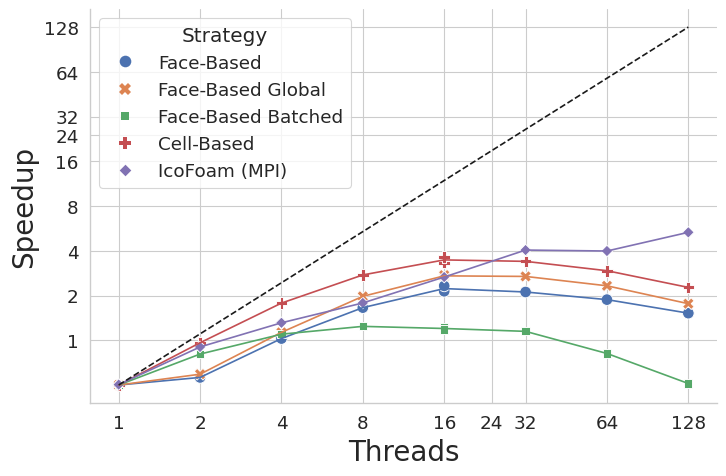

In [211]:
scaling_speedup(all[(all["Threads"] < 256) & (all["cells"] == 8000000)])

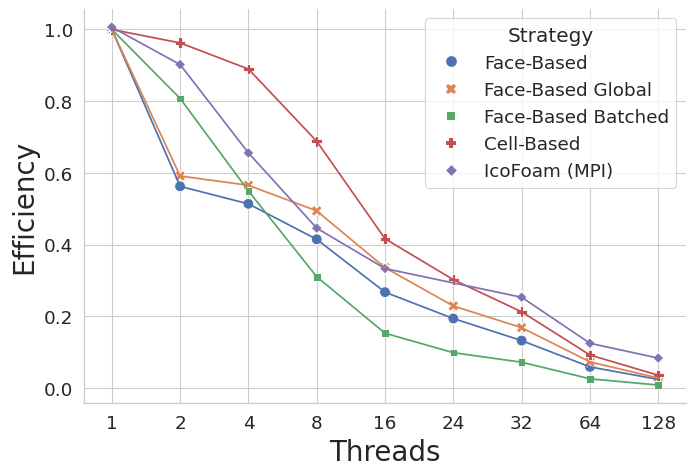

In [220]:
def scaling_efficiency(data):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.5):

        plot = sb.relplot(data=data, x="threadindex", y="avg_efficiency", kind="scatter", style="strategy", hue="strategy", s=60)
        axes = plot.axes.flat

        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data,
                x="threadindex",
                y="avg_efficiency",
                hue="strategy",
                legend=False,   # avoid duplicate legends
                ax=ax
            )
            ax.tick_params(labelbottom=True)
            ax.set_xticks(list(range(1,10)))
            ax.set_xticklabels(labels=sorted(data["Threads"].unique()))
            ax.set_xlabel("Threads")
        handles, labels = axes[0].get_legend_handles_labels()
        sb.move_legend(plot, "upper right", fancybox=True)
        plot.legend.remove()
        plt.ylabel("Efficiency", fontsize=20)
        plt.xlabel("Threads", fontsize=20)
        axes[0].legend(handles,  all["strategy_display"].unique(), loc="upper right",
                        title="Strategy")

        plt.tight_layout()
        plt.savefig("../figures/icoFoam-julia-efficiency.svg")

scaling_efficiency(all[all["Threads"] < 256])

In [193]:
sorted(all["cells"].unique())

[np.int64(1000),
 np.int64(8000),
 np.int64(27000),
 np.int64(64000),
 np.int64(125000),
 np.int64(216000),
 np.int64(343000),
 np.int64(512000),
 np.int64(729000),
 np.int64(1000000),
 np.int64(1728000),
 np.int64(2744000),
 np.int64(4096000),
 np.int64(5832000),
 np.int64(8000000),
 np.int64(10648000),
 np.int64(13824000),
 np.int64(17576000),
 np.int64(21952000),
 np.int64(27000000),
 np.int64(32768000),
 np.int64(39304000),
 np.int64(46656000),
 np.int64(54872000),
 np.int64(64000000)]

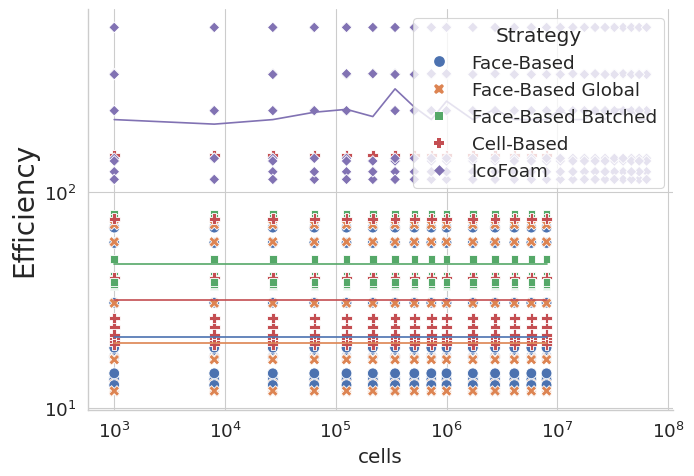

In [199]:
def scaling_ms(data):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.5):

        plot = sb.relplot(data=data, x="cells", y="avg_time", kind="scatter", style="strategy", hue="strategy", s=60)
        axes = plot.axes.flat
        plot.set(
            xscale="log",
            yscale="log"
        )
        for i, ax in enumerate(axes):
            sb.lineplot(
                data=data,
                x="cells",
                y="avg_time",
                hue="strategy",
                legend=False,   # avoid duplicate legends
                ax=ax,
                err_style=None
            )
            # ax.tick_params(labelbottom=True)
            # ax.set_xticks(list(range(1,11)))
            # ax.set_xticklabels(labels=sorted(data["Threads"].unique()))
            # ax.set_xlabel("Threads")
        handles, labels = axes[0].get_legend_handles_labels()
        sb.move_legend(plot, "upper right", fancybox=True)
        plot.legend.remove()
        plt.ylabel("Efficiency", fontsize=20)
        # plt.xlabel("Threads", fontsize=20)
        axes[0].legend(handles,  all["strategy_display"].unique(), loc="upper right",
                        title="Strategy")

        plt.tight_layout()
scaling_ms(all)